# Embedding Layer 테스트

In [2]:
from transformers import AutoTokenizer
from loguru import logger
from model import Encoder, Decoder, Seq2Seq

import torch

In [ ]:
def get_model_from_checkpoint(checkpoint, device):
    embedding_dim = int(checkpoint["embedding_dim"])
    hidden_dim = int(checkpoint["hidden_dim"])
    kor_vocab_size = int(checkpoint["kor_vocab_size"])
    en_vocab_size = int(checkpoint["en_vocab_size"])
    
    encoder = Encoder(kor_vocab_size, embedding_dim, hidden_dim)
    decoder = Decoder(en_vocab_size, embedding_dim, hidden_dim)
    model = Seq2Seq(encoder, decoder, padding_id = int(checkpoint.get("pad_token_id", 0)))
    
    model.load_state_dict(checkpoint["seq2seq_state_dict"], strict = True)
    model.to(device)
    model.eval()
    return model

def load_checkpoint(path, device):
    checkpoint = torch.load(path, map_location = device)
    
    required = ["seq2seq_state_dict", "embedding_dim", "hidden_dim", "kor_vocab_size", "en_vocab_size"]
    missing = [k for k in required if k not in checkpoint]
    
    if missing:
        raise KeyError(f"Missiong keys in checkpoint: {missing}")
    return checkpoint

device = "cuda" if torch.cuda.is_available() else "mps"

kor_tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
en_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

model_checkpoint_path = "checkpoints/best.pt"
model = load_checkpoint(model_checkpoint_path, device = device)

logger.info(f"Loaded checkpoint from {model_checkpoint_path}")

model = get_model_from_checkpoint(model, device = device)

embedding_matrix = model.encoder.embedding.weight.detach()
token_id = kor_tokenizer.encode("고양이", add_special_tokens = False)[0]

vec = embedding_matrix[token_id]
sims = torch.cosine_similarity(vec.unsqueeze(0), embedding_matrix)
topk = torch.topk(sims, k = 10)
logger.info(f"'고양이'와 유사한 토큰:\n{kor_tokenizer.convert_ids_to_tokens(topk.indices.tolist())}")

2026-05-08 05:51:08.830 | INFO     | __main__:<module>:34 - Loaded checkpoint from checkpoints/best.pt
2026-05-08 05:51:09.239 | INFO     | __main__:<module>:44 - '고양이'와 유사한 토큰:['고양이', '원가', '담화', '고속도로', '##공원', '기제', '서진', '벤', '냐', '222']


---
# 데이터셋 확인

### 1. Helsinki-NLP/opus-100

In [1]:
from datasets import load_dataset
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import numpy as np

kor_tokenizer = AutoTokenizer.from_pretrained("klue/bert-base")
en_tokenizer  = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

dataset = load_dataset("Helsinki-NLP/opus-100", "en-ko")

# train + valid + test 전체 합산
all_ko = []
all_en = []

for split in ["train", "validation", "test"]:
    for sample in dataset[split]:
        ko_text = sample["translation"]["ko"]
        en_text = sample["translation"]["en"]
        # 특수 토큰(CLS, SEP) 제외한 실제 내용 토큰 수
        ko_len = len(kor_tokenizer.tokenize(ko_text))
        en_len = len(en_tokenizer.tokenize(en_text))
        all_ko.append(ko_len)
        all_en.append(en_len)

print(f"전체 샘플 수: {len(all_ko):,}")
print(f"\n[한국어] 평균: {np.mean(all_ko):.1f} / 중앙값: {np.median(all_ko):.1f} / 최대: {max(all_ko)} / 최소: {min(all_ko)}")
print(f"[영 어] 평균: {np.mean(all_en):.1f} / 중앙값: {np.median(all_en):.1f} / 최대: {max(all_en)} / 최소: {min(all_en)}")

/root/RNN_Translator/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (913 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (665 > 512). Running this sequence through the model will result in indexing errors


전체 샘플 수: 1,004,000

[한국어] 평균: 10.9 / 중앙값: 8.0 / 최대: 1911 / 최소: 0
[영 어] 평균: 10.8 / 중앙값: 9.0 / 최대: 665 / 최소: 0


In [16]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 157 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (42.1 MB/s)    
debconf: delaying package configuration, since apt-utils is not installed
Selecting previously unselected package fonts-nanum.
(Reading database ... 26294 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
/bin/bash: line 1: fc-cache: command not found


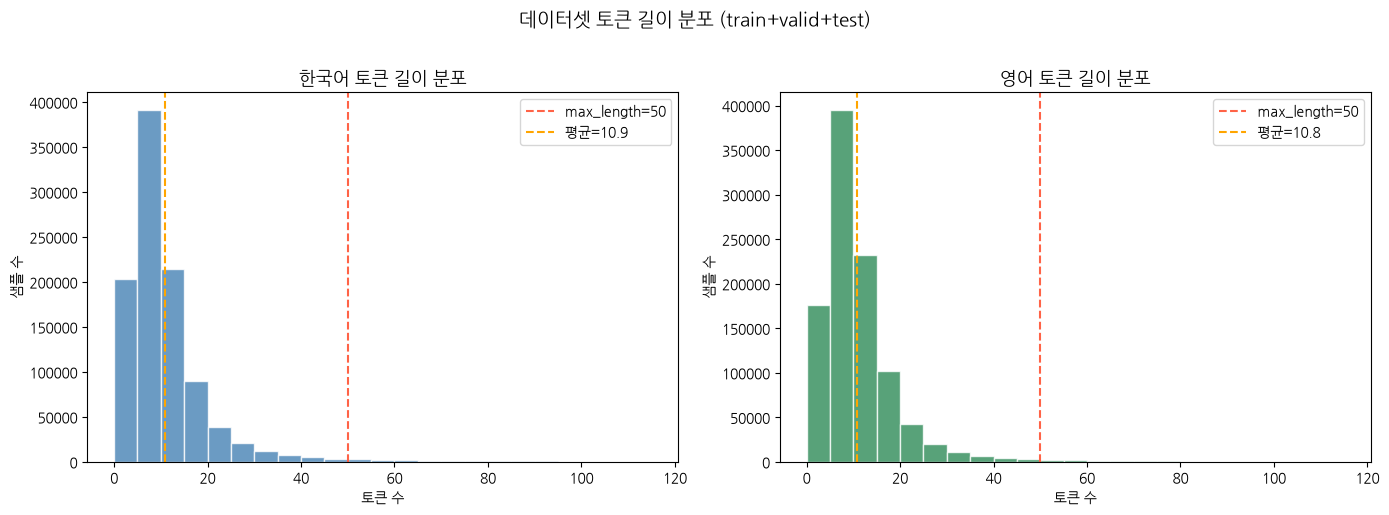


max_length=50 초과 샘플 비율
  한국어: 14,636 / 1,004,000 (1.5%)
  영 어: 9,635 / 1,004,000 (1.0%)


In [ ]:
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = range(0, 120, 5)

# 한국어
axes[0].hist(all_ko, bins=bins, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(50, color="tomato", linestyle="--", linewidth=1.5, label="max_length=50")
axes[0].axvline(np.mean(all_ko), color="orange", linestyle="--", linewidth=1.5, label=f"평균={np.mean(all_ko):.1f}")
axes[0].set_title("한국어 토큰 길이 분포", fontsize=13)
axes[0].set_xlabel("토큰 수")
axes[0].set_ylabel("샘플 수")
axes[0].legend()

# 영어
axes[1].hist(all_en, bins=bins, color="seagreen", alpha=0.8, edgecolor="white")
axes[1].axvline(50, color="tomato", linestyle="--", linewidth=1.5, label="max_length=50")
axes[1].axvline(np.mean(all_en), color="orange", linestyle="--", linewidth=1.5, label=f"평균={np.mean(all_en):.1f}")
axes[1].set_title("영어 토큰 길이 분포", fontsize=13)
axes[1].set_xlabel("토큰 수")
axes[1].set_ylabel("샘플 수")
axes[1].legend()

plt.suptitle("데이터셋 토큰 길이 분포 (train+valid+test)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# max_length=50 초과 비율
ko_over = sum(1 for l in all_ko if l > 50)
en_over = sum(1 for l in all_en if l > 50)
print(f"\nmax_length=50 초과 샘플 비율")
print(f"  한국어: {ko_over:,} / {len(all_ko):,} ({ko_over/len(all_ko)*100:.1f}%)")
print(f"  영 어: {en_over:,} / {len(all_en):,} ({en_over/len(all_en)*100:.1f}%)")